In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("paysim.csv")

In [3]:
print(df.head())
print(df.info())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 co

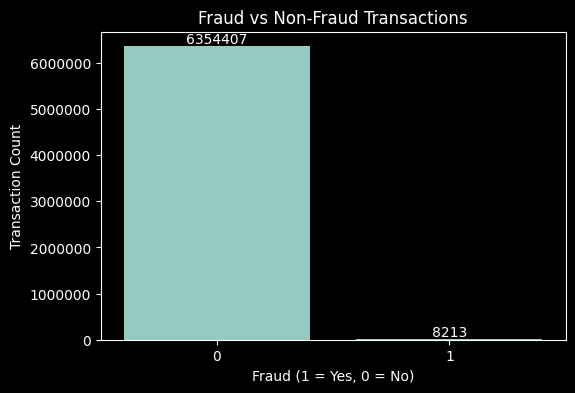

In [4]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='isFraud', data=df)

# Add count labels as integers
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud (1 = Yes, 0 = No)")
plt.ylabel("Transaction Count")

# Prevent scientific notation on axis
plt.ticklabel_format(style='plain', axis='y')

plt.show()

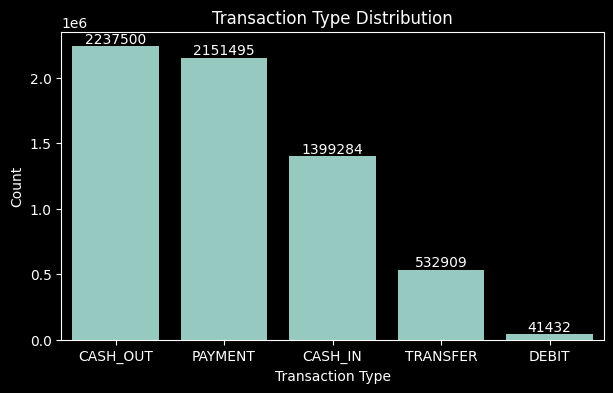

In [5]:
plt.figure(figsize=(7,4))
ax = sns.countplot(x='type', data=df, order=df['type'].value_counts().index)

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

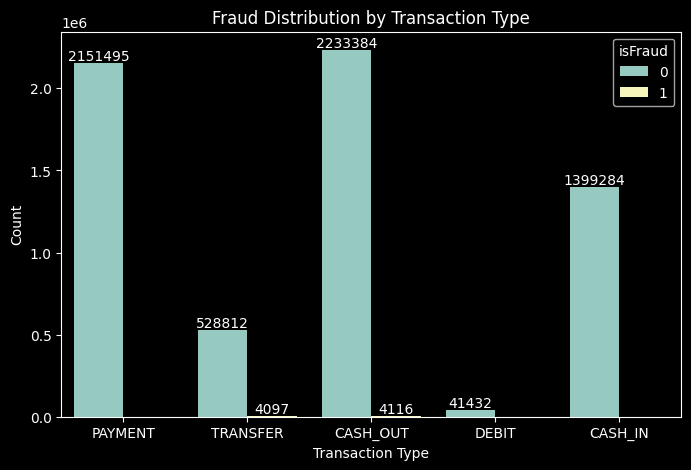

In [6]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='type', hue='isFraud', data=df)

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title("Fraud Distribution by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

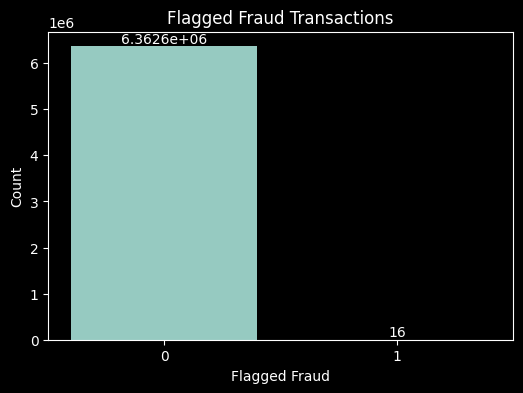

In [7]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='isFlaggedFraud', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Flagged Fraud Transactions")
plt.xlabel("Flagged Fraud")
plt.ylabel("Count")

plt.show()

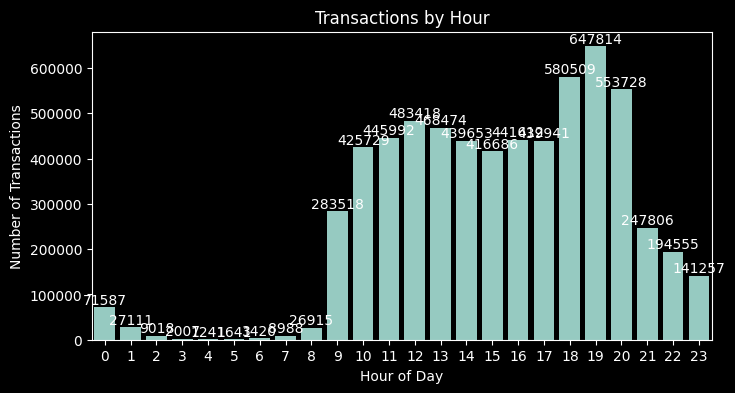

In [8]:
df['hour'] = df['step'] % 24

plt.figure(figsize=(8,4))

ax = sns.countplot(x='hour', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

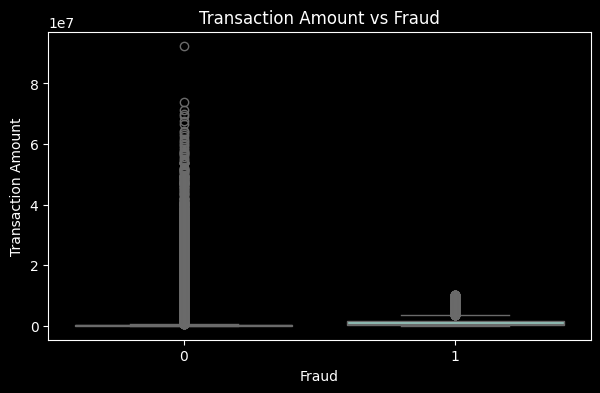

In [9]:
plt.figure(figsize=(7,4))

sns.boxplot(x='isFraud', y='amount', data=df)

plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud")
plt.ylabel("Transaction Amount")

plt.show()

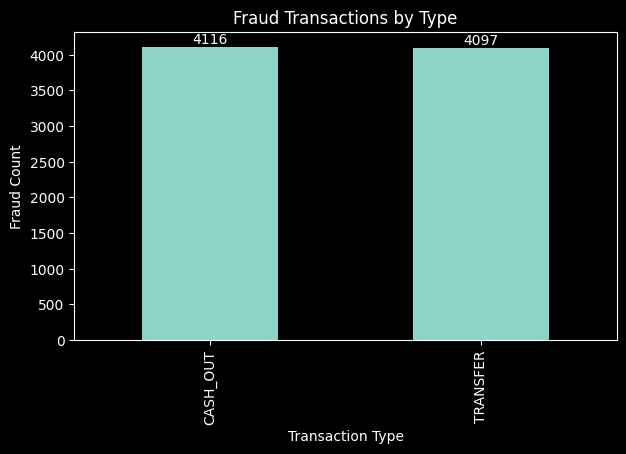

In [10]:
fraud_counts = df[df['isFraud']==1]['type'].value_counts()

ax = fraud_counts.plot(kind='bar', figsize=(7,4))

for container in ax.containers:
    ax.bar_label(container)

plt.title("Fraud Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Count")

plt.show()

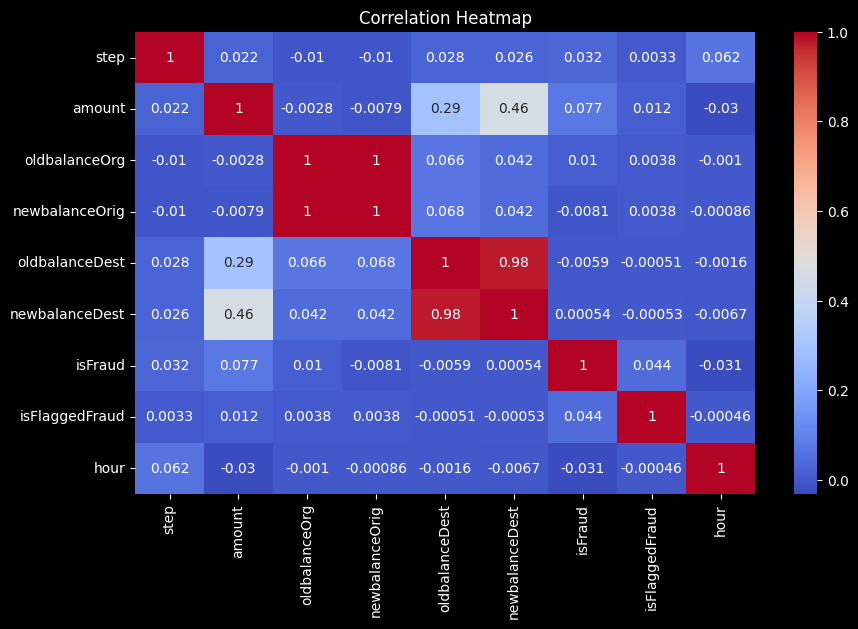

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()